In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

#Step 1: Loading the Dataset and main statistics

In [2]:
df = pd.read_csv('dataset.csv')
df

,f1,f2,f3,f4,f5,f6,f7,target
0,6,148,72,35,0,33.6,0.627,1
1,1,85,66,29,0,26.6,0.351,0
2,8,183,64,0,0,23.3,0.672,1
3,1,89,66,23,94,28.1,0.167,0
4,0,137,40,35,168,43.1,2.288,1
...,...,...,...,...,...,...,...,...
761,9,89,62,0,0,22.5,e,0
762,10,101,76,48,180,d,0.171,0
763,2,122,70,27,b,36.8,0.34,0
764,c,121,72,23,112,26.2,0.245,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766 entries, 0 to 765
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   f1      766 non-null    object
 1   f2      766 non-null    object
 2   f3      766 non-null    int64 
 3   f4      766 non-null    object
 4   f5      766 non-null    object
 5   f6      766 non-null    object
 6   f7      766 non-null    object
 7   target  766 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 48.0+ KB


-> Except f3 and target, remaining columns are object data type. Need to convert them to numerical data type to generate insights. Also need to handle the invalid character entries.

In [4]:
for column in df.columns:
  if df[column].dtype == object:
    unique_values = df[column].unique()
    #print(unique_values)

    invalid_values = []
    for value in unique_values:
      try:
        float(value)
      except ValueError:
        invalid_values.append(value)

    if invalid_values:
      print(f"Invalid values found in column '{column}': {invalid_values}")
      df[column] = df[column].replace(invalid_values, 0)

    df[column] = pd.to_numeric(df[column])

Invalid values found in column 'f1': ['c']
Invalid values found in column 'f2': ['f']
Invalid values found in column 'f4': ['a']
Invalid values found in column 'f5': ['b']
Invalid values found in column 'f6': ['d']
Invalid values found in column 'f7': ['e']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766 entries, 0 to 765
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      766 non-null    int64  
 1   f2      766 non-null    int64  
 2   f3      766 non-null    int64  
 3   f4      766 non-null    int64  
 4   f5      766 non-null    int64  
 5   f6      766 non-null    float64
 6   f7      766 non-null    float64
 7   target  766 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 48.0 KB


In [6]:
df.describe()

,f1,f2,f3,f4,f5,f6,f7,target
count,766.000000,766.000000,766.000000,766.000000,766.000000,766.000000,766.000000,766.000000
mean,3.844648,120.751958,69.118799,20.515666,79.986945,31.956397,0.471512,0.349869
std,3.374358,32.224557,19.376901,15.967341,115.335259,7.977334,0.331767,0.477240
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,99.000000,62.500000,0.000000,0.000000,27.300000,0.243250,0.000000
50%,3.000000,117.000000,72.000000,23.000000,34.000000,32.000000,0.372500,0.000000
75%,6.000000,140.000000,80.000000,32.000000,127.750000,36.600000,0.625500,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,1.000000


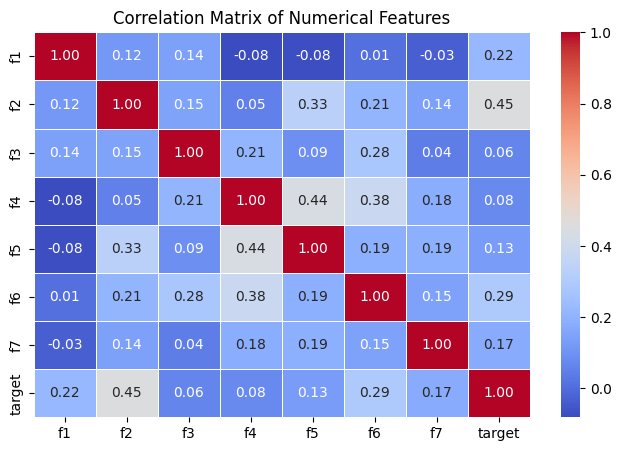

In [ ]:
# Heatmap of correlations between numerical features (Resuing from A1)
columns = df.columns
plt.figure(figsize=(8, 5))
correlation_matrix = df[columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

target
0    498
1    268
Name: target, dtype: int64


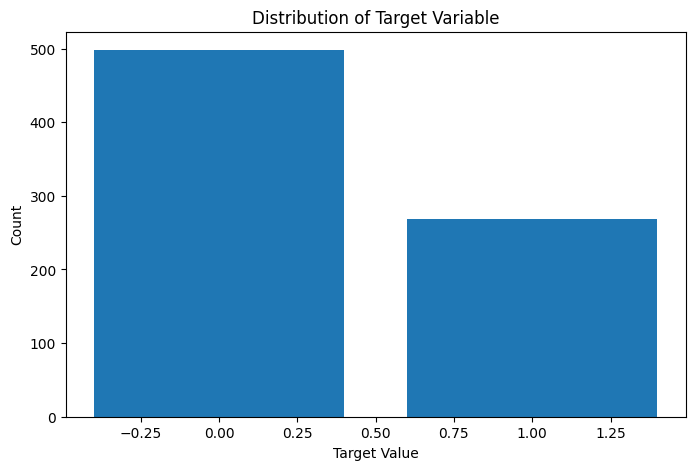

In [ ]:
#Resuing from Assignment 1
plt.figure(figsize=(8, 5))
target_value = df.groupby('target')['target'].count()
plt.bar(target_value.index, target_value.values)
plt.title('Distribution of Target Variable')
plt.xlabel('Target Value')
plt.ylabel('Count')
print(target_value)

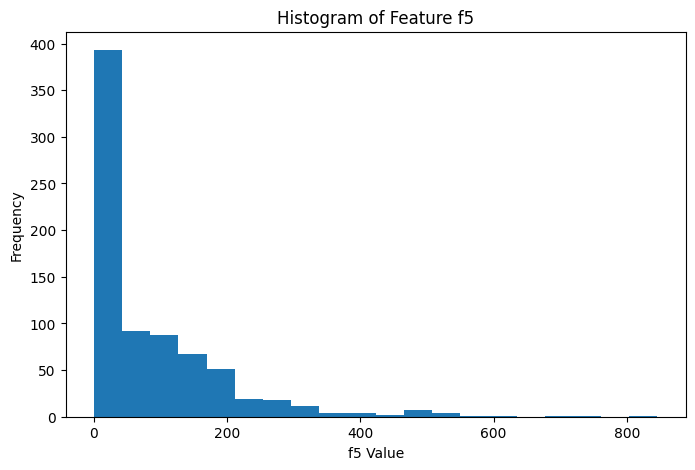

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['f5'], bins=20)
plt.title('Histogram of Feature f5')
plt.xlabel('f5 Value')
plt.ylabel('Frequency')
plt.show()

#Step 2: Preprocessing and Splitting the **Dataset**

In [70]:
df

,f1,f2,f3,f4,f5,f6,f7,target
0,6,148,72,35,0,33.6,0.627,1
1,1,85,66,29,0,26.6,0.351,0
2,8,183,64,0,0,23.3,0.672,1
3,1,89,66,23,94,28.1,0.167,0
4,0,137,40,35,168,43.1,2.288,1
...,...,...,...,...,...,...,...,...
761,9,89,62,0,0,22.5,0.000,0
762,10,101,76,48,180,0.0,0.171,0
763,2,122,70,27,0,36.8,0.340,0
764,0,121,72,23,112,26.2,0.245,0


In [71]:
X = df.drop('target', axis = 1)
y = df['target']

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

#Using test_size = 0.11 to maintain equal sizes of val and test dataset. It's not compulsory though
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.11, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

(613, 7) (76, 7) (77, 7) (613,) (76,) (77,)


In [73]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [74]:
print("Class distribution in y_train:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in y_val:")
print(y_val.value_counts(normalize=True))

print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

Class distribution in y_train:
target
0    0.652529
1    0.347471
Name: proportion, dtype: float64

Class distribution in y_val:
target
0    0.684211
1    0.315789
Name: proportion, dtype: float64

Class distribution in y_test:
target
0    0.597403
1    0.402597
Name: proportion, dtype: float64


In [75]:
#Converting np arrays to tensors using torch.tensor()
X_train_tensor = torch.tensor(X_train.astype(np.float32))
y_train_tensor = torch.tensor(y_train.values.astype(np.float32))
X_val_tensor = torch.tensor(X_val.astype(np.float32))
y_val_tensor = torch.tensor(y_val.values.astype(np.float32))
X_test_tensor = torch.tensor(X_test.astype(np.float32))
y_test_tensor = torch.tensor(y_test.values.astype(np.float32))

In [76]:
X_train_tensor.size()

torch.Size([613, 7])

#Step 3: Defining the Neural Network

In [77]:
#Input neuron size
num_of_features = X_train.shape[1]
num_of_features

7

In [78]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super(NeuralNetwork, self).__init__()

    #self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
      nn.Linear(7, 128),
      nn.ReLU(),
      nn.Dropout(0.4),
      nn.Linear(128, 64),
      nn.ReLU(),
      nn.Dropout(0.4),
      nn.Linear(64, 1),
      nn.Sigmoid()
      )
  def forward(self, x):
    #x = self.flatten(x)
    x = self.linear_relu_stack(x)
    return x

In [79]:
#!pip install torchinfo
from torchinfo import summary

model = NeuralNetwork()
summary(model, input_size=(1, num_of_features))

Layer (type:depth-idx)                   Output Shape              Param #
NeuralNetwork                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 128]                  1,024
│    └─ReLU: 2-2                         [1, 128]                  --
│    └─Dropout: 2-3                      [1, 128]                  --
│    └─Linear: 2-4                       [1, 64]                   8,256
│    └─ReLU: 2-5                         [1, 64]                   --
│    └─Dropout: 2-6                      [1, 64]                   --
│    └─Linear: 2-7                       [1, 1]                    65
│    └─Sigmoid: 2-8                      [1, 1]                    --
Total params: 9,345
Trainable params: 9,345
Non-trainable params: 0
Total mult-adds (M): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04

#Step 4: Training the Neural Network

In [80]:
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight

loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [81]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

In [82]:
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

for inputs, targets in train_loader:
  print("Train loader:")
  print("Inputs shape:", inputs.shape)
  print("Targets shape:", targets.shape)
  break

for inputs, targets in val_loader:
  print("Validation loader:")
  print("Inputs shape:", inputs.shape)
  print("Targets shape:", targets.shape)
  break

for inputs, targets in test_loader:
  print("Test loader:")
  print("Inputs shape:", inputs.shape)
  print("Targets shape:", targets.shape)
  break

Train loader:
Inputs shape: torch.Size([16, 7])
Targets shape: torch.Size([16])
Validation loader:
Inputs shape: torch.Size([16, 7])
Targets shape: torch.Size([16])
Test loader:
Inputs shape: torch.Size([16, 7])
Targets shape: torch.Size([16])


In [83]:
import time
epochs = 35
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        labels = labels.unsqueeze(1)
        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = loss_function(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(epoch_train_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_labels = val_labels.unsqueeze(1)
            val_outputs = model(val_inputs)

            epoch_val_loss += loss_function(val_outputs, val_labels).item()
            val_predicted = (val_outputs > 0.5).float()
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_val / total_val)

    # Print epoch results
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')
    #print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Validation Loss: {val_losses[-1]}')

print(f"Training time: {time.time() - start} seconds")

Epoch 1/35, Train Loss: 0.6550312684132502, Train Accuracy: 0.6215334420880914, Validation Loss: 0.5535309433937072, Validation Accuracy: 0.7763157894736842
Epoch 2/35, Train Loss: 0.55671038153844, Train Accuracy: 0.7389885807504079, Validation Loss: 0.47925240993499757, Validation Accuracy: 0.8157894736842105
Epoch 3/35, Train Loss: 0.5013347696035336, Train Accuracy: 0.768352365415987, Validation Loss: 0.46956280469894407, Validation Accuracy: 0.7763157894736842
Epoch 4/35, Train Loss: 0.4837333682255867, Train Accuracy: 0.765089722675367, Validation Loss: 0.4714530646800995, Validation Accuracy: 0.7894736842105263
Epoch 5/35, Train Loss: 0.5058533786199032, Train Accuracy: 0.763458401305057, Validation Loss: 0.46827816069126127, Validation Accuracy: 0.7763157894736842
Epoch 6/35, Train Loss: 0.4939873061883144, Train Accuracy: 0.7830342577487766, Validation Loss: 0.48008530735969546, Validation Accuracy: 0.7763157894736842
Epoch 7/35, Train Loss: 0.4691347865722118, Train Accuracy:

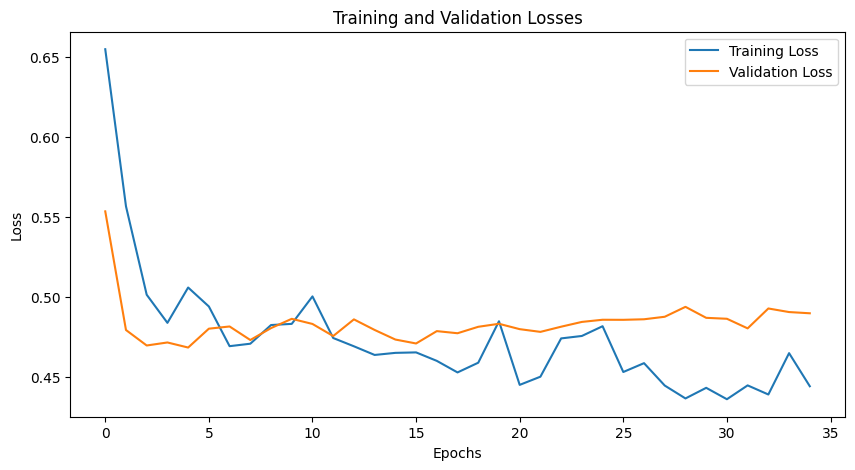

In [84]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

In [85]:
#Checking accuracy on test dataset
model.eval()
test_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        test_loss += loss_function(outputs, labels.unsqueeze(1)).item()
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy on test data: {accuracy}")
print(f"Test Loss: {test_loss / len(test_loader)}")

Accuracy on test data: 0.7532467532467533
Test Loss: 0.5435027837753296


In [86]:
test_accuracy = accuracy
test_loss = test_loss / len(test_loader)

test_accuracy_list = [test_accuracy] * epochs
test_loss_list = [test_loss] * epochs

print(test_accuracy_list)
print(test_loss_list)

[0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533, 0.7532467532467533]
[0.5435027837753296, 0.5435027837753296, 0.5435027837753296, 0.5435027837753296, 0.5435027837753296, 0.5435027837753296, 0.5435027837753296, 0.5435027837753296, 0.5435027837753296, 0.5435027837753296, 0.5435027837753296, 0.5435027837753296, 0.5435027837753296, 0.5435027837753296, 0.5435027837753296

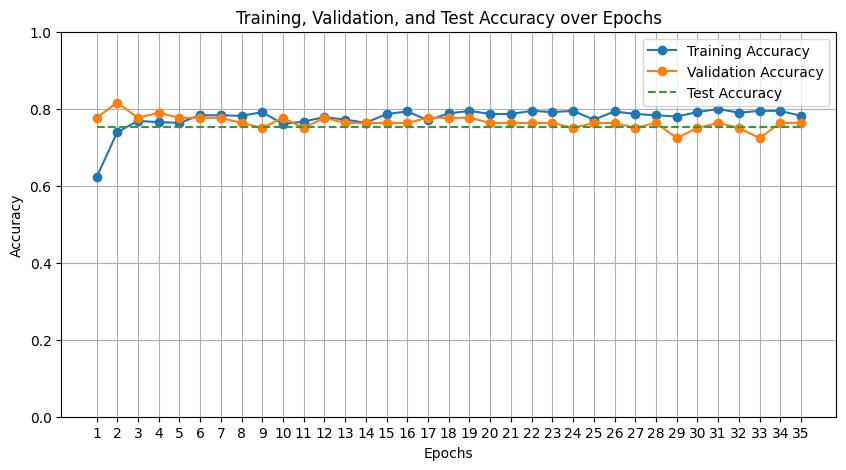

In [87]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_accuracies, label='Training Accuracy', marker='o')
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', marker='o')
plt.plot(range(1, epochs + 1), test_accuracy_list, label='Test Accuracy', linestyle='--')

plt.title('Training, Validation, and Test Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(np.arange(1, epochs + 1, step=1))
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()

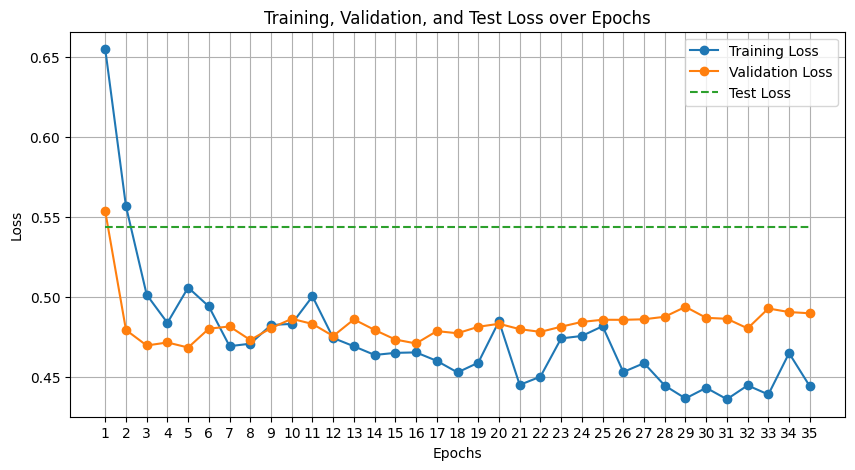

In [88]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', marker='o')
plt.plot(range(1, epochs + 1), test_loss_list, label='Test Loss', linestyle='--')

plt.title('Training, Validation, and Test Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(np.arange(1, epochs + 1, step=1))
plt.grid()
plt.legend()
plt.show()

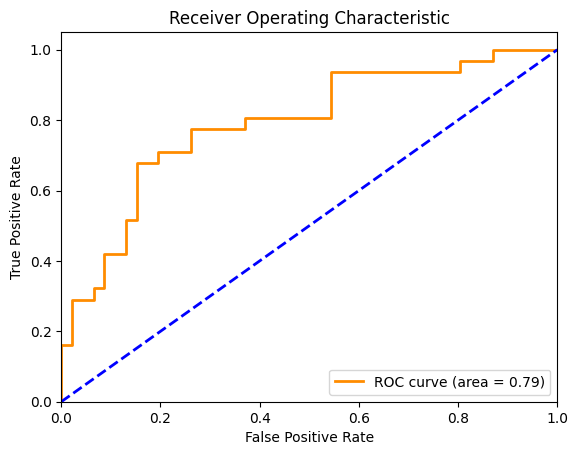

In [89]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_score, recall_score, f1_score

model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        y_true.extend(labels.cpu().numpy())
        y_scores.extend(outputs.cpu().numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores).flatten()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Precision: 0.6875
Recall: 0.7096774193548387
F1-score: 0.6984126984126984


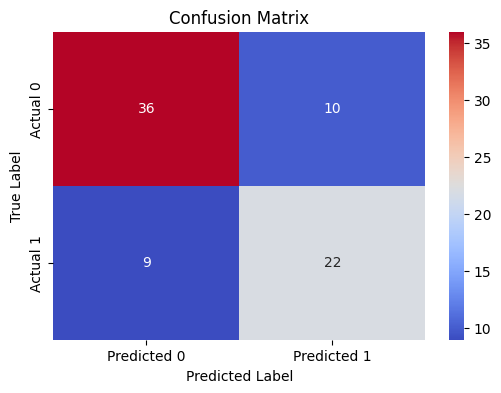

In [90]:
# Confusion Matrix & Precision, Recall, F1-Score
y_pred = (y_scores > 0.5).astype(int)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [91]:
#Saving best model weights as per the lowest val_loss
best_epoch = np.argmin(val_losses)
print(f"Best epoch: {best_epoch + 1}")

torch.save(model.state_dict(), 'base_model.pth')

Best epoch: 5


In [ ]:
#Loading best_model to cross-check if weights were saved properly
best_model = NeuralNetwork()
best_model.load_state_dict(torch.load('base_model.pth'))
best_model.to(device)

#Checking accuracy on test dataset again
best_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy using loaded model on test data: {accuracy}")

Accuracy using loaded model on test data: 0.7532467532467533


<ipython-input-131-ebf4b1890ea9>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load('base_model.pth'))


# Part II : Optimizing NN

###Testing LR

In [95]:
#LR - 0.0001
model = NeuralNetwork()
model.to(device)
print(summary(model, input_size=(1, num_of_features)))

loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

Layer (type:depth-idx)                   Output Shape              Param #
NeuralNetwork                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 128]                  1,024
│    └─ReLU: 2-2                         [1, 128]                  --
│    └─Dropout: 2-3                      [1, 128]                  --
│    └─Linear: 2-4                       [1, 64]                   8,256
│    └─ReLU: 2-5                         [1, 64]                   --
│    └─Dropout: 2-6                      [1, 64]                   --
│    └─Linear: 2-7                       [1, 1]                    65
│    └─Sigmoid: 2-8                      [1, 1]                    --
Total params: 9,345
Trainable params: 9,345
Non-trainable params: 0
Total mult-adds (M): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04


In [96]:
import time
epochs = 35
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        labels = labels.unsqueeze(1)
        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = loss_function(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(epoch_train_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_labels = val_labels.unsqueeze(1)
            val_outputs = model(val_inputs)

            epoch_val_loss += loss_function(val_outputs, val_labels).item()
            val_predicted = (val_outputs > 0.5).float()
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_val / total_val)

    # Print epoch results
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')
    #print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Validation Loss: {val_losses[-1]}')

print(f"Training time: {time.time() - start} seconds")

Epoch 1/35, Train Loss: 0.7034980058670044, Train Accuracy: 0.42251223491027734, Validation Loss: 0.6908892035484314, Validation Accuracy: 0.47368421052631576
Epoch 2/35, Train Loss: 0.6919070589236724, Train Accuracy: 0.5089722675367048, Validation Loss: 0.6706055641174317, Validation Accuracy: 0.7236842105263158
Epoch 3/35, Train Loss: 0.6768340071042379, Train Accuracy: 0.6182707993474714, Validation Loss: 0.6529556155204773, Validation Accuracy: 0.8026315789473685
Epoch 4/35, Train Loss: 0.6624101385092124, Train Accuracy: 0.6916802610114192, Validation Loss: 0.6369467854499817, Validation Accuracy: 0.8157894736842105
Epoch 5/35, Train Loss: 0.6440918430303916, Train Accuracy: 0.7063621533442088, Validation Loss: 0.6224603295326233, Validation Accuracy: 0.8157894736842105
Epoch 6/35, Train Loss: 0.6288708158028431, Train Accuracy: 0.7096247960848288, Validation Loss: 0.6069190740585327, Validation Accuracy: 0.7894736842105263
Epoch 7/35, Train Loss: 0.614605419146709, Train Accurac

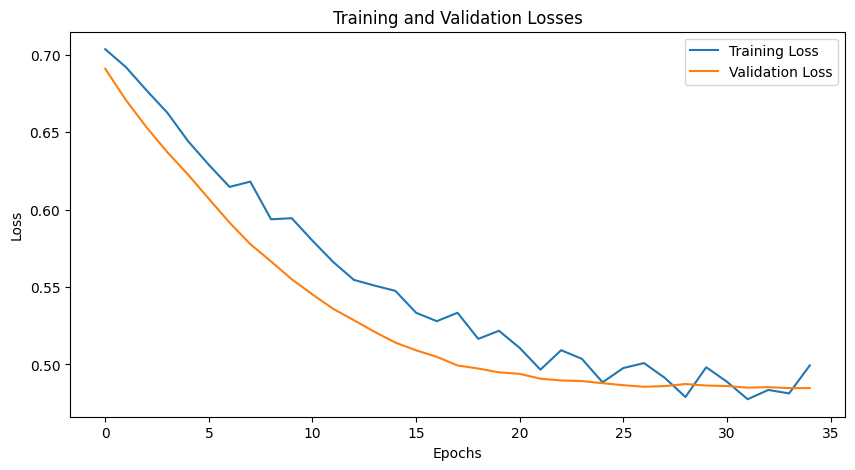

In [97]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

In [98]:
#Checking accuracy on test dataset
model.eval()
test_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        test_loss += loss_function(outputs, labels.unsqueeze(1)).item()
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy on test data: {accuracy}")
print(f"Test Loss: {test_loss / len(test_loader)}")

Accuracy on test data: 0.7532467532467533
Test Loss: 0.5015653669834137


In [99]:
#LR - 0.0003
model = NeuralNetwork()
model.to(device)
summary(model, input_size=(1, num_of_features))

loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)

In [100]:
import time
epochs = 35
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        labels = labels.unsqueeze(1)
        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = loss_function(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(epoch_train_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_labels = val_labels.unsqueeze(1)
            val_outputs = model(val_inputs)

            epoch_val_loss += loss_function(val_outputs, val_labels).item()
            val_predicted = (val_outputs > 0.5).float()
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_val / total_val)

    # Print epoch results
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')
    #print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Validation Loss: {val_losses[-1]}')

print(f"Training time: {time.time() - start} seconds")

Epoch 1/35, Train Loss: 0.6597093099202865, Train Accuracy: 0.6492659053833605, Validation Loss: 0.6203073620796203, Validation Accuracy: 0.6842105263157895
Epoch 2/35, Train Loss: 0.6204608373152904, Train Accuracy: 0.6835236541598695, Validation Loss: 0.5806055903434754, Validation Accuracy: 0.7631578947368421
Epoch 3/35, Train Loss: 0.5942290295393039, Train Accuracy: 0.7047308319738989, Validation Loss: 0.5479232132434845, Validation Accuracy: 0.8026315789473685
Epoch 4/35, Train Loss: 0.5685093036064734, Train Accuracy: 0.7014681892332789, Validation Loss: 0.5212310910224914, Validation Accuracy: 0.8026315789473685
Epoch 5/35, Train Loss: 0.529745238713729, Train Accuracy: 0.7422512234910277, Validation Loss: 0.5030133783817291, Validation Accuracy: 0.8026315789473685
Epoch 6/35, Train Loss: 0.5278462293820504, Train Accuracy: 0.7487765089722676, Validation Loss: 0.4928887069225311, Validation Accuracy: 0.7894736842105263
Epoch 7/35, Train Loss: 0.5075686344733605, Train Accuracy:

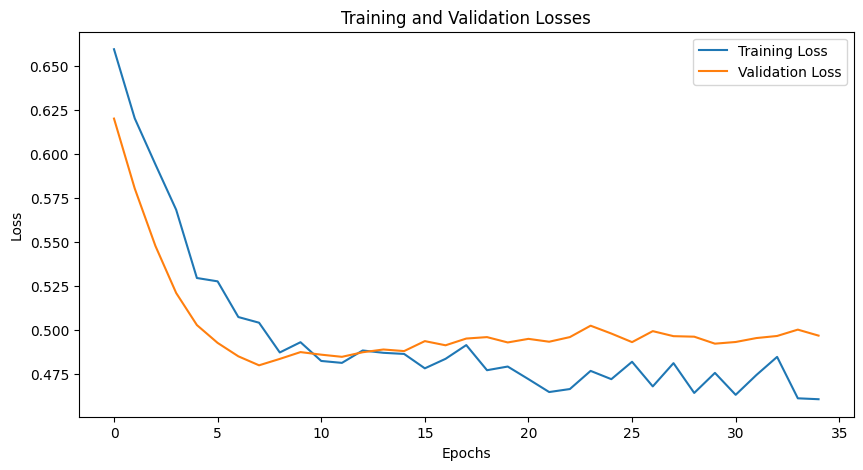

In [101]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

In [102]:
#Checking accuracy on test dataset
model.eval()
test_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        test_loss += loss_function(outputs, labels.unsqueeze(1)).item()
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy on test data: {accuracy}")
print(f"Test Loss: {test_loss / len(test_loader)}")

Accuracy on test data: 0.7272727272727273
Test Loss: 0.5248952507972717


In [103]:
#LR - 0.003
model = NeuralNetwork()
model.to(device)
print(summary(model, input_size=(1, num_of_features)))

loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

Layer (type:depth-idx)                   Output Shape              Param #
NeuralNetwork                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 128]                  1,024
│    └─ReLU: 2-2                         [1, 128]                  --
│    └─Dropout: 2-3                      [1, 128]                  --
│    └─Linear: 2-4                       [1, 64]                   8,256
│    └─ReLU: 2-5                         [1, 64]                   --
│    └─Dropout: 2-6                      [1, 64]                   --
│    └─Linear: 2-7                       [1, 1]                    65
│    └─Sigmoid: 2-8                      [1, 1]                    --
Total params: 9,345
Trainable params: 9,345
Non-trainable params: 0
Total mult-adds (M): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04


In [104]:
import time
epochs = 30
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        labels = labels.unsqueeze(1)
        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = loss_function(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(epoch_train_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_labels = val_labels.unsqueeze(1)
            val_outputs = model(val_inputs)

            epoch_val_loss += loss_function(val_outputs, val_labels).item()
            val_predicted = (val_outputs > 0.5).float()
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_val / total_val)

    # Print epoch results
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')
    #print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Validation Loss: {val_losses[-1]}')

print(f"Training time: {time.time() - start} seconds")

Epoch 1/30, Train Loss: 0.5655135611693064, Train Accuracy: 0.7194127243066885, Validation Loss: 0.463063645362854, Validation Accuracy: 0.7894736842105263
Epoch 2/30, Train Loss: 0.49913396743627697, Train Accuracy: 0.7569331158238173, Validation Loss: 0.4705594122409821, Validation Accuracy: 0.7894736842105263
Epoch 3/30, Train Loss: 0.49663749031531507, Train Accuracy: 0.766721044045677, Validation Loss: 0.475643116235733, Validation Accuracy: 0.7894736842105263
Epoch 4/30, Train Loss: 0.477145838813904, Train Accuracy: 0.7781402936378466, Validation Loss: 0.49495199918746946, Validation Accuracy: 0.7763157894736842
Epoch 5/30, Train Loss: 0.48921241821386874, Train Accuracy: 0.7585644371941273, Validation Loss: 0.4884046226739883, Validation Accuracy: 0.7763157894736842
Epoch 6/30, Train Loss: 0.4697160766674922, Train Accuracy: 0.7765089722675367, Validation Loss: 0.4735689997673035, Validation Accuracy: 0.7894736842105263
Epoch 7/30, Train Loss: 0.4867793795390007, Train Accuracy

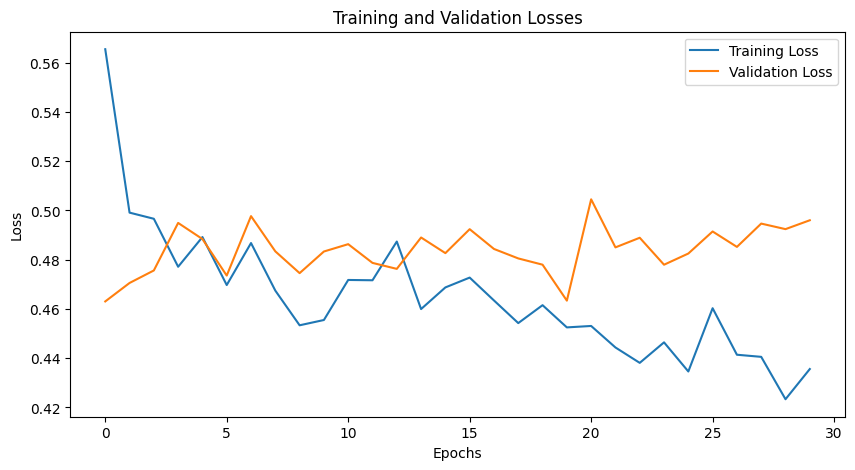

In [105]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

In [106]:
#Checking accuracy on test dataset
model.eval()
test_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        test_loss += loss_function(outputs, labels.unsqueeze(1)).item()
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy on test data: {accuracy}")
print(f"Test Loss: {test_loss / len(test_loader)}")

Accuracy on test data: 0.7402597402597403
Test Loss: 0.5555492103099823


###Testing batch sizes

Batch Size - 32

In [107]:
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

for inputs, targets in train_loader:
  print("Train loader:")
  print("Inputs shape:", inputs.shape)
  print("Targets shape:", targets.shape)
  break

for inputs, targets in val_loader:
  print("Validation loader:")
  print("Inputs shape:", inputs.shape)
  print("Targets shape:", targets.shape)
  break

for inputs, targets in test_loader:
  print("Test loader:")
  print("Inputs shape:", inputs.shape)
  print("Targets shape:", targets.shape)
  break

Train loader:
Inputs shape: torch.Size([32, 7])
Targets shape: torch.Size([32])
Validation loader:
Inputs shape: torch.Size([32, 7])
Targets shape: torch.Size([32])
Test loader:
Inputs shape: torch.Size([32, 7])
Targets shape: torch.Size([32])


In [112]:
model = NeuralNetwork()
model.to(device)
print(summary(model, input_size=(1, num_of_features)))

loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Layer (type:depth-idx)                   Output Shape              Param #
NeuralNetwork                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 128]                  1,024
│    └─ReLU: 2-2                         [1, 128]                  --
│    └─Dropout: 2-3                      [1, 128]                  --
│    └─Linear: 2-4                       [1, 64]                   8,256
│    └─ReLU: 2-5                         [1, 64]                   --
│    └─Dropout: 2-6                      [1, 64]                   --
│    └─Linear: 2-7                       [1, 1]                    65
│    └─Sigmoid: 2-8                      [1, 1]                    --
Total params: 9,345
Trainable params: 9,345
Non-trainable params: 0
Total mult-adds (M): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04


In [113]:
epochs = 35
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        labels = labels.unsqueeze(1)
        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = loss_function(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(epoch_train_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_labels = val_labels.unsqueeze(1)
            val_outputs = model(val_inputs)

            epoch_val_loss += loss_function(val_outputs, val_labels).item()
            val_predicted = (val_outputs > 0.5).float()
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_val / total_val)

    # Print epoch results
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')
    #print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Validation Loss: {val_losses[-1]}')

print(f"Training time: {time.time() - start} seconds")

Epoch 1/35, Train Loss: 0.6458889156579971, Train Accuracy: 0.6851549755301795, Validation Loss: 0.5613606373469034, Validation Accuracy: 0.8026315789473685
Epoch 2/35, Train Loss: 0.562001782655716, Train Accuracy: 0.7373572593800979, Validation Loss: 0.5058086713155111, Validation Accuracy: 0.8289473684210527
Epoch 3/35, Train Loss: 0.524235463142395, Train Accuracy: 0.7569331158238173, Validation Loss: 0.48099129398663837, Validation Accuracy: 0.8026315789473685
Epoch 4/35, Train Loss: 0.5104995593428612, Train Accuracy: 0.7601957585644372, Validation Loss: 0.48452502489089966, Validation Accuracy: 0.8157894736842105
Epoch 5/35, Train Loss: 0.4978926882147789, Train Accuracy: 0.768352365415987, Validation Loss: 0.4873477617899577, Validation Accuracy: 0.8026315789473685
Epoch 6/35, Train Loss: 0.4850204803049564, Train Accuracy: 0.766721044045677, Validation Loss: 0.49158285061518353, Validation Accuracy: 0.8026315789473685
Epoch 7/35, Train Loss: 0.4709939956665039, Train Accuracy:

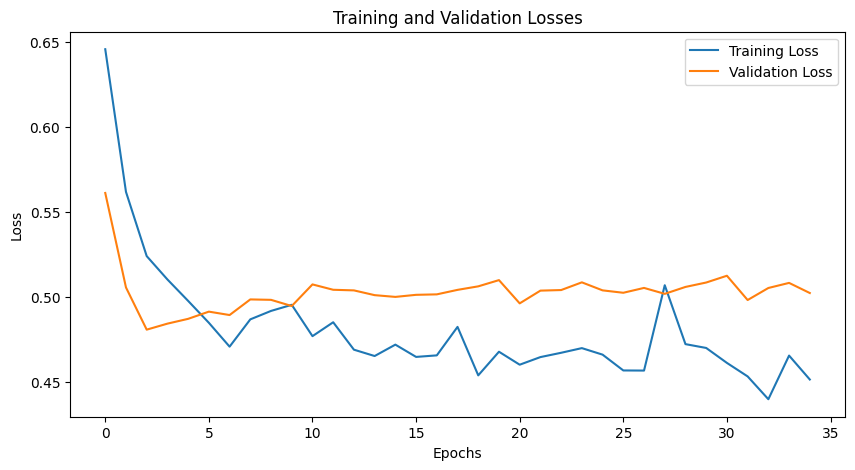

In [114]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

In [115]:
#Checking accuracy on test dataset
model.eval()
test_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        test_loss += loss_function(outputs, labels.unsqueeze(1)).item()
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy on test data: {accuracy}")
print(f"Test Loss: {test_loss / len(test_loader)}")

Accuracy on test data: 0.7402597402597403
Test Loss: 0.5151410500208536


Batch Size - 8

In [116]:
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

for inputs, targets in train_loader:
  print("Train loader:")
  print("Inputs shape:", inputs.shape)
  print("Targets shape:", targets.shape)
  break

for inputs, targets in val_loader:
  print("Validation loader:")
  print("Inputs shape:", inputs.shape)
  print("Targets shape:", targets.shape)
  break

for inputs, targets in test_loader:
  print("Test loader:")
  print("Inputs shape:", inputs.shape)
  print("Targets shape:", targets.shape)
  break

Train loader:
Inputs shape: torch.Size([8, 7])
Targets shape: torch.Size([8])
Validation loader:
Inputs shape: torch.Size([8, 7])
Targets shape: torch.Size([8])
Test loader:
Inputs shape: torch.Size([8, 7])
Targets shape: torch.Size([8])


In [117]:
model = NeuralNetwork()
model.to(device)
print(summary(model, input_size=(1, num_of_features)))

loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Layer (type:depth-idx)                   Output Shape              Param #
NeuralNetwork                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 128]                  1,024
│    └─ReLU: 2-2                         [1, 128]                  --
│    └─Dropout: 2-3                      [1, 128]                  --
│    └─Linear: 2-4                       [1, 64]                   8,256
│    └─ReLU: 2-5                         [1, 64]                   --
│    └─Dropout: 2-6                      [1, 64]                   --
│    └─Linear: 2-7                       [1, 1]                    65
│    └─Sigmoid: 2-8                      [1, 1]                    --
Total params: 9,345
Trainable params: 9,345
Non-trainable params: 0
Total mult-adds (M): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04


In [118]:
import time
epochs = 35
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        labels = labels.unsqueeze(1)
        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = loss_function(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(epoch_train_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_labels = val_labels.unsqueeze(1)
            val_outputs = model(val_inputs)

            epoch_val_loss += loss_function(val_outputs, val_labels).item()
            val_predicted = (val_outputs > 0.5).float()
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_val / total_val)

    # Print epoch results
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')
    #print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Validation Loss: {val_losses[-1]}')

print(f"Training time: {time.time() - start} seconds")

Epoch 1/35, Train Loss: 0.6087053243990068, Train Accuracy: 0.6965742251223491, Validation Loss: 0.49791801273822783, Validation Accuracy: 0.8026315789473685
Epoch 2/35, Train Loss: 0.5122399558494617, Train Accuracy: 0.7569331158238173, Validation Loss: 0.47195199579000474, Validation Accuracy: 0.7894736842105263
Epoch 3/35, Train Loss: 0.49165921784066535, Train Accuracy: 0.7455138662316476, Validation Loss: 0.47748187333345415, Validation Accuracy: 0.7894736842105263
Epoch 4/35, Train Loss: 0.47778249919027477, Train Accuracy: 0.7601957585644372, Validation Loss: 0.47272028028964996, Validation Accuracy: 0.8026315789473685
Epoch 5/35, Train Loss: 0.47590195610151664, Train Accuracy: 0.7781402936378466, Validation Loss: 0.47286669760942457, Validation Accuracy: 0.7894736842105263
Epoch 6/35, Train Loss: 0.47592781638944304, Train Accuracy: 0.7781402936378466, Validation Loss: 0.4722644105553627, Validation Accuracy: 0.8026315789473685
Epoch 7/35, Train Loss: 0.4894175734612849, Train

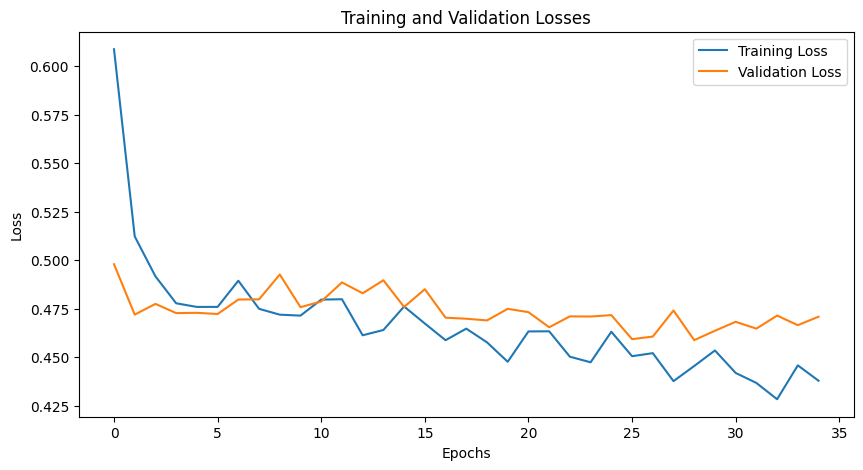

In [119]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

In [120]:
#Checking accuracy on test dataset
model.eval()
test_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        test_loss += loss_function(outputs, labels.unsqueeze(1)).item()
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy on test data: {accuracy}")
print(f"Test Loss: {test_loss / len(test_loader)}")

Accuracy on test data: 0.7532467532467533
Test Loss: 0.5344832628965378


Batch Size - 64

In [121]:
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

for inputs, targets in train_loader:
  print("Train loader:")
  print("Inputs shape:", inputs.shape)
  print("Targets shape:", targets.shape)
  break

for inputs, targets in val_loader:
  print("Validation loader:")
  print("Inputs shape:", inputs.shape)
  print("Targets shape:", targets.shape)
  break

for inputs, targets in test_loader:
  print("Test loader:")
  print("Inputs shape:", inputs.shape)
  print("Targets shape:", targets.shape)
  break

Train loader:
Inputs shape: torch.Size([64, 7])
Targets shape: torch.Size([64])
Validation loader:
Inputs shape: torch.Size([64, 7])
Targets shape: torch.Size([64])
Test loader:
Inputs shape: torch.Size([64, 7])
Targets shape: torch.Size([64])


In [122]:
model = NeuralNetwork()
model.to(device)
print(summary(model, input_size=(1, num_of_features)))

loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Layer (type:depth-idx)                   Output Shape              Param #
NeuralNetwork                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 128]                  1,024
│    └─ReLU: 2-2                         [1, 128]                  --
│    └─Dropout: 2-3                      [1, 128]                  --
│    └─Linear: 2-4                       [1, 64]                   8,256
│    └─ReLU: 2-5                         [1, 64]                   --
│    └─Dropout: 2-6                      [1, 64]                   --
│    └─Linear: 2-7                       [1, 1]                    65
│    └─Sigmoid: 2-8                      [1, 1]                    --
Total params: 9,345
Trainable params: 9,345
Non-trainable params: 0
Total mult-adds (M): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04


In [123]:
import time
epochs = 30
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        labels = labels.unsqueeze(1)
        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = loss_function(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(epoch_train_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_labels = val_labels.unsqueeze(1)
            val_outputs = model(val_inputs)

            epoch_val_loss += loss_function(val_outputs, val_labels).item()
            val_predicted = (val_outputs > 0.5).float()
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_val / total_val)

    # Print epoch results
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')
    #print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Validation Loss: {val_losses[-1]}')

print(f"Training time: {time.time() - start} seconds")

Epoch 1/30, Train Loss: 0.6485888481140136, Train Accuracy: 0.6639477977161501, Validation Loss: 0.5971403121948242, Validation Accuracy: 0.7631578947368421
Epoch 2/30, Train Loss: 0.5965999782085418, Train Accuracy: 0.7079934747145188, Validation Loss: 0.5455507040023804, Validation Accuracy: 0.8026315789473685
Epoch 3/30, Train Loss: 0.5493796408176422, Train Accuracy: 0.7373572593800979, Validation Loss: 0.5185967087745667, Validation Accuracy: 0.8157894736842105
Epoch 4/30, Train Loss: 0.5212381929159164, Train Accuracy: 0.7716150081566069, Validation Loss: 0.5062859952449799, Validation Accuracy: 0.8157894736842105
Epoch 5/30, Train Loss: 0.5035886853933335, Train Accuracy: 0.766721044045677, Validation Loss: 0.49852511286735535, Validation Accuracy: 0.8157894736842105
Epoch 6/30, Train Loss: 0.492188373208046, Train Accuracy: 0.7748776508972267, Validation Loss: 0.5058779865503311, Validation Accuracy: 0.8026315789473685
Epoch 7/30, Train Loss: 0.4948111563920975, Train Accuracy:

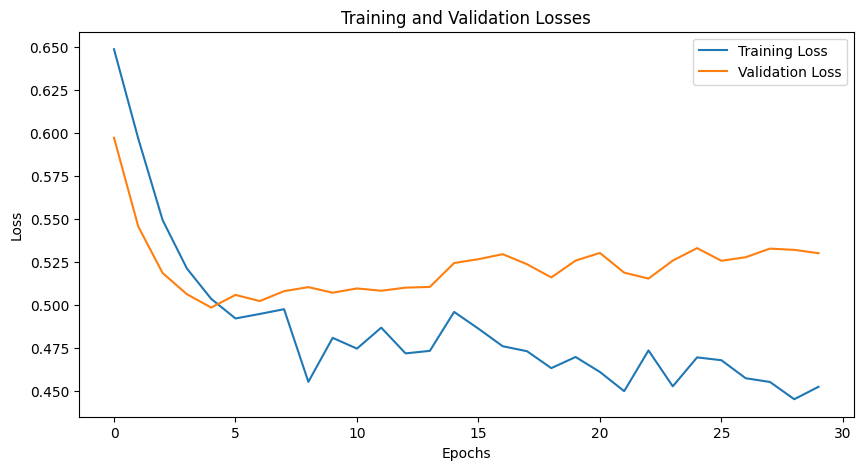

In [124]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

In [125]:
#Checking accuracy on test dataset
model.eval()
test_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        test_loss += loss_function(outputs, labels.unsqueeze(1)).item()
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy on test data: {accuracy}")
print(f"Test Loss: {test_loss / len(test_loader)}")

Accuracy on test data: 0.7272727272727273
Test Loss: 0.4899587035179138


###Testing number of epochs

Epochs - 25

In [152]:
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

for inputs, targets in train_loader:
  print("Train loader:")
  print("Inputs shape:", inputs.shape)
  print("Targets shape:", targets.shape)
  break

for inputs, targets in val_loader:
  print("Validation loader:")
  print("Inputs shape:", inputs.shape)
  print("Targets shape:", targets.shape)
  break

for inputs, targets in test_loader:
  print("Test loader:")
  print("Inputs shape:", inputs.shape)
  print("Targets shape:", targets.shape)
  break

Train loader:
Inputs shape: torch.Size([16, 7])
Targets shape: torch.Size([16])
Validation loader:
Inputs shape: torch.Size([16, 7])
Targets shape: torch.Size([16])
Test loader:
Inputs shape: torch.Size([16, 7])
Targets shape: torch.Size([16])


In [153]:
model = NeuralNetwork()
model.to(device)
print(summary(model, input_size=(1, num_of_features)))

loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Layer (type:depth-idx)                   Output Shape              Param #
NeuralNetwork                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 128]                  1,024
│    └─ReLU: 2-2                         [1, 128]                  --
│    └─Dropout: 2-3                      [1, 128]                  --
│    └─Linear: 2-4                       [1, 64]                   8,256
│    └─ReLU: 2-5                         [1, 64]                   --
│    └─Dropout: 2-6                      [1, 64]                   --
│    └─Linear: 2-7                       [1, 1]                    65
│    └─Sigmoid: 2-8                      [1, 1]                    --
Total params: 9,345
Trainable params: 9,345
Non-trainable params: 0
Total mult-adds (M): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04


In [154]:
import time
epochs = 25
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        labels = labels.unsqueeze(1)
        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = loss_function(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(epoch_train_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_labels = val_labels.unsqueeze(1)
            val_outputs = model(val_inputs)

            epoch_val_loss += loss_function(val_outputs, val_labels).item()
            val_predicted = (val_outputs > 0.5).float()
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_val / total_val)

    # Print epoch results
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')
    #print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Validation Loss: {val_losses[-1]}')

print(f"Training time: {time.time() - start} seconds")

Epoch 1/25, Train Loss: 0.615828410937236, Train Accuracy: 0.6704730831973899, Validation Loss: 0.5349771022796631, Validation Accuracy: 0.7894736842105263
Epoch 2/25, Train Loss: 0.537472359645061, Train Accuracy: 0.7210440456769984, Validation Loss: 0.4849680423736572, Validation Accuracy: 0.7894736842105263
Epoch 3/25, Train Loss: 0.5023504052406702, Train Accuracy: 0.7569331158238173, Validation Loss: 0.4662089467048645, Validation Accuracy: 0.7894736842105263
Epoch 4/25, Train Loss: 0.48298976054558385, Train Accuracy: 0.7699836867862969, Validation Loss: 0.4771406531333923, Validation Accuracy: 0.7894736842105263
Epoch 5/25, Train Loss: 0.4769469029628314, Train Accuracy: 0.7716150081566069, Validation Loss: 0.4811387866735458, Validation Accuracy: 0.8026315789473685
Epoch 6/25, Train Loss: 0.4672966259412276, Train Accuracy: 0.7765089722675367, Validation Loss: 0.48276946842670443, Validation Accuracy: 0.7631578947368421
Epoch 7/25, Train Loss: 0.47819089889526367, Train Accurac

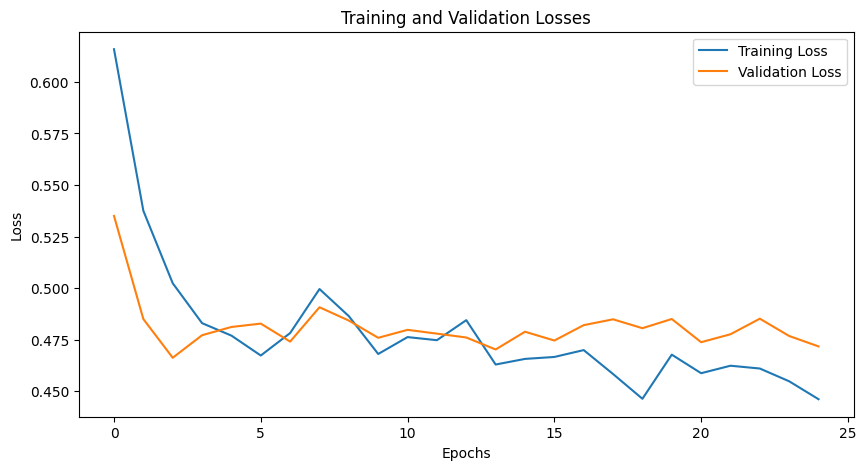

In [155]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

In [156]:
#Checking accuracy on test dataset
model.eval()
test_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        test_loss += loss_function(outputs, labels.unsqueeze(1)).item()
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy on test data: {accuracy}")
print(f"Test Loss: {test_loss / len(test_loader)}")

Accuracy on test data: 0.7532467532467533
Test Loss: 0.536707478761673


Epochs - 30

In [157]:
model = NeuralNetwork()
model.to(device)
print(summary(model, input_size=(1, num_of_features)))

loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Layer (type:depth-idx)                   Output Shape              Param #
NeuralNetwork                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 128]                  1,024
│    └─ReLU: 2-2                         [1, 128]                  --
│    └─Dropout: 2-3                      [1, 128]                  --
│    └─Linear: 2-4                       [1, 64]                   8,256
│    └─ReLU: 2-5                         [1, 64]                   --
│    └─Dropout: 2-6                      [1, 64]                   --
│    └─Linear: 2-7                       [1, 1]                    65
│    └─Sigmoid: 2-8                      [1, 1]                    --
Total params: 9,345
Trainable params: 9,345
Non-trainable params: 0
Total mult-adds (M): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04


In [158]:
epochs = 30
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        labels = labels.unsqueeze(1)
        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = loss_function(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(epoch_train_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_labels = val_labels.unsqueeze(1)
            val_outputs = model(val_inputs)

            epoch_val_loss += loss_function(val_outputs, val_labels).item()
            val_predicted = (val_outputs > 0.5).float()
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_val / total_val)

    # Print epoch results
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')
    #print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Validation Loss: {val_losses[-1]}')

print(f"Training time: {time.time() - start} seconds")

Epoch 1/30, Train Loss: 0.6120547812718612, Train Accuracy: 0.6851549755301795, Validation Loss: 0.5184850037097931, Validation Accuracy: 0.8157894736842105
Epoch 2/30, Train Loss: 0.5284134470499479, Train Accuracy: 0.7569331158238173, Validation Loss: 0.4802009642124176, Validation Accuracy: 0.8157894736842105
Epoch 3/30, Train Loss: 0.5012652094547565, Train Accuracy: 0.7716150081566069, Validation Loss: 0.481511253118515, Validation Accuracy: 0.7763157894736842
Epoch 4/30, Train Loss: 0.49656744339527226, Train Accuracy: 0.7585644371941273, Validation Loss: 0.4806684345006943, Validation Accuracy: 0.75
Epoch 5/30, Train Loss: 0.4718828124877734, Train Accuracy: 0.7732463295269169, Validation Loss: 0.4751995116472244, Validation Accuracy: 0.8026315789473685
Epoch 6/30, Train Loss: 0.49383327670586413, Train Accuracy: 0.7553017944535073, Validation Loss: 0.4867359191179276, Validation Accuracy: 0.7894736842105263
Epoch 7/30, Train Loss: 0.48347744192832554, Train Accuracy: 0.76019575

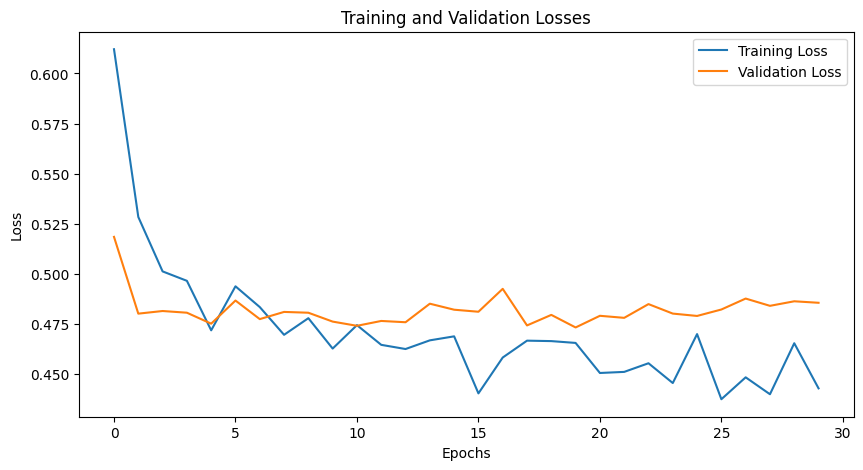

Accuracy on test data: 0.7532467532467533
Test Loss: 0.5234008431434631


In [159]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

#Checking accuracy on test dataset
model.eval()
test_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        test_loss += loss_function(outputs, labels.unsqueeze(1)).item()
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy on test data: {accuracy}")
print(f"Test Loss: {test_loss / len(test_loader)}")

In [160]:
model = NeuralNetwork()
model.to(device)
print(summary(model, input_size=(1, num_of_features)))

loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Layer (type:depth-idx)                   Output Shape              Param #
NeuralNetwork                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 128]                  1,024
│    └─ReLU: 2-2                         [1, 128]                  --
│    └─Dropout: 2-3                      [1, 128]                  --
│    └─Linear: 2-4                       [1, 64]                   8,256
│    └─ReLU: 2-5                         [1, 64]                   --
│    └─Dropout: 2-6                      [1, 64]                   --
│    └─Linear: 2-7                       [1, 1]                    65
│    └─Sigmoid: 2-8                      [1, 1]                    --
Total params: 9,345
Trainable params: 9,345
Non-trainable params: 0
Total mult-adds (M): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04


Epochs - 40

In [161]:
import time
epochs = 40
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        labels = labels.unsqueeze(1)
        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = loss_function(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(epoch_train_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_labels = val_labels.unsqueeze(1)
            val_outputs = model(val_inputs)

            epoch_val_loss += loss_function(val_outputs, val_labels).item()
            val_predicted = (val_outputs > 0.5).float()
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_val / total_val)

    # Print epoch results
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')
    #print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Validation Loss: {val_losses[-1]}')

print(f"Training time: {time.time() - start} seconds")

Epoch 1/40, Train Loss: 0.651342301032482, Train Accuracy: 0.6150081566068516, Validation Loss: 0.5465504169464112, Validation Accuracy: 0.8289473684210527
Epoch 2/40, Train Loss: 0.5406347948771256, Train Accuracy: 0.7406199021207178, Validation Loss: 0.4884756326675415, Validation Accuracy: 0.8289473684210527
Epoch 3/40, Train Loss: 0.5153907239437103, Train Accuracy: 0.763458401305057, Validation Loss: 0.4834736526012421, Validation Accuracy: 0.7894736842105263
Epoch 4/40, Train Loss: 0.49094208234395736, Train Accuracy: 0.765089722675367, Validation Loss: 0.49074646532535554, Validation Accuracy: 0.8026315789473685
Epoch 5/40, Train Loss: 0.49590480938935894, Train Accuracy: 0.766721044045677, Validation Loss: 0.4959854304790497, Validation Accuracy: 0.7763157894736842
Epoch 6/40, Train Loss: 0.48833906268462157, Train Accuracy: 0.7797716150081566, Validation Loss: 0.49530946612358095, Validation Accuracy: 0.7763157894736842
Epoch 7/40, Train Loss: 0.48270181432748455, Train Accura

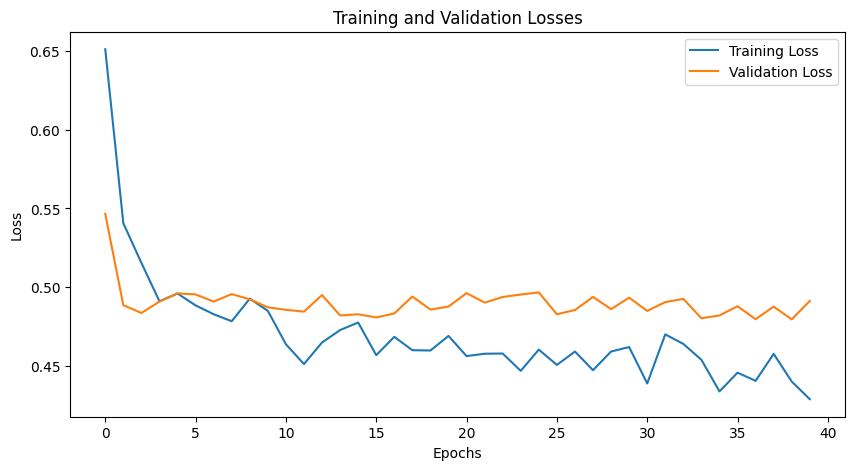

Accuracy on test data: 0.7532467532467533
Test Loss: 0.5464692711830139


In [162]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

#Checking accuracy on test dataset
model.eval()
test_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        test_loss += loss_function(outputs, labels.unsqueeze(1)).item()
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy on test data: {accuracy}")
print(f"Test Loss: {test_loss / len(test_loader)}")

#Improving the base model with LR - 0.001, Batch Size - 16 and Epochs - 35




In [163]:
#Loading best_model to cross-check if weights were saved properly
best_model = NeuralNetwork()
best_model.load_state_dict(torch.load('base_model.pth'))
best_model.to(device)

#Checking accuracy on test dataset again
best_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

best_accuracy = correct / total
print(f"Accuracy using loaded model on test data: {best_accuracy}")

Accuracy using loaded model on test data: 0.7532467532467533


<ipython-input-163-fa020fc071d0>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load('base_model.pth'))


##Learning Rate Scheduler

In [166]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model = NeuralNetwork()
model.to(device)
summary(model, input_size=(1, num_of_features))

loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True) #LR Scheduler

epochs = 35
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        labels = labels.unsqueeze(1)
        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = loss_function(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(epoch_train_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_labels = val_labels.unsqueeze(1)
            val_outputs = model(val_inputs)

            epoch_val_loss += loss_function(val_outputs, val_labels).item()
            val_predicted = (val_outputs > 0.5).float()
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_val / total_val)

    scheduler.step(val_losses[-1])

    # Print epoch results
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')

print(f"Training time: {time.time() - start} seconds")

Epoch 1/35, Train Loss: 0.6341028244067461, Train Accuracy: 0.6525285481239804, Validation Loss: 0.5462806701660157, Validation Accuracy: 0.8157894736842105
Epoch 2/35, Train Loss: 0.5370774895716937, Train Accuracy: 0.7471451876019576, Validation Loss: 0.4917681455612183, Validation Accuracy: 0.8289473684210527
Epoch 3/35, Train Loss: 0.4996209060534453, Train Accuracy: 0.7569331158238173, Validation Loss: 0.4805450260639191, Validation Accuracy: 0.8289473684210527
Epoch 4/35, Train Loss: 0.4875129384872241, Train Accuracy: 0.768352365415987, Validation Loss: 0.492385795712471, Validation Accuracy: 0.7894736842105263
Epoch 5/35, Train Loss: 0.4715088800742076, Train Accuracy: 0.7765089722675367, Validation Loss: 0.4828111320734024, Validation Accuracy: 0.8026315789473685
Epoch 6/35, Train Loss: 0.4760377468206944, Train Accuracy: 0.7732463295269169, Validation Loss: 0.4854596138000488, Validation Accuracy: 0.7894736842105263
Epoch 7/35, Train Loss: 0.49284984935552645, Train Accuracy:

Accuracy on test data: 0.7532467532467533
Test Loss: 0.5177288830280304


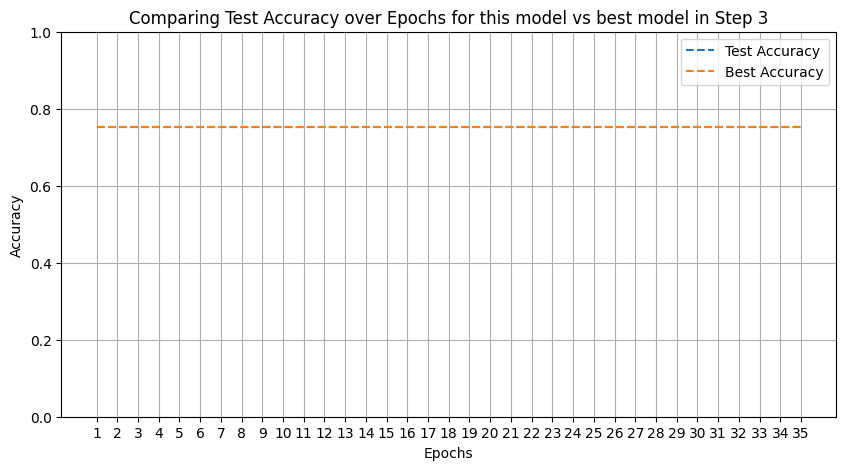

In [167]:
#Checking accuracy on test dataset
model.eval()
test_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        test_loss += loss_function(outputs, labels.unsqueeze(1)).item()
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy on test data: {accuracy}")
print(f"Test Loss: {test_loss / len(test_loader)}")

test_accuracy = accuracy

test_accuracy_list = [test_accuracy] * epochs
best_accuracy_list = [best_accuracy] * epochs

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), test_accuracy_list, label='Test Accuracy', linestyle='--')
plt.plot(range(1, epochs + 1), best_accuracy_list, label='Best Accuracy', linestyle='--')

plt.title('Comparing Test Accuracy over Epochs for this model vs best model in Step 3')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(np.arange(1, epochs + 1, step=1))
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()

##Batch Normalization

In [168]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super(NeuralNetwork, self).__init__()

    #self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
      nn.Linear(7, 128),
      nn.BatchNorm1d(128),
      nn.ReLU(),
      nn.Dropout(0.4),
      nn.Linear(128, 64),
      nn.BatchNorm1d(64),
      nn.ReLU(),
      nn.Dropout(0.4),
      nn.Linear(64, 1),
      nn.Sigmoid()
      )
  def forward(self, x):
    #x = self.flatten(x)
    x = self.linear_relu_stack(x)
    return x

In [169]:
model = NeuralNetwork()
model.to(device)
print(summary(model, input_size=(1, num_of_features)))

loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 35
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        labels = labels.unsqueeze(1)
        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = loss_function(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(epoch_train_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_labels = val_labels.unsqueeze(1)
            val_outputs = model(val_inputs)

            epoch_val_loss += loss_function(val_outputs, val_labels).item()
            val_predicted = (val_outputs > 0.5).float()
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_val / total_val)


    # Print epoch results
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')

print(f"Training time: {time.time() - start} seconds")

Layer (type:depth-idx)                   Output Shape              Param #
NeuralNetwork                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 128]                  1,024
│    └─BatchNorm1d: 2-2                  [1, 128]                  256
│    └─ReLU: 2-3                         [1, 128]                  --
│    └─Dropout: 2-4                      [1, 128]                  --
│    └─Linear: 2-5                       [1, 64]                   8,256
│    └─BatchNorm1d: 2-6                  [1, 64]                   128
│    └─ReLU: 2-7                         [1, 64]                   --
│    └─Dropout: 2-8                      [1, 64]                   --
│    └─Linear: 2-9                       [1, 1]                    65
│    └─Sigmoid: 2-10                     [1, 1]                    --
Total params: 9,729
Trainable params: 9,729
Non-trainable params: 0
Total mul

Accuracy on test data: 0.7532467532467533
Test Loss: 0.5339621245861054


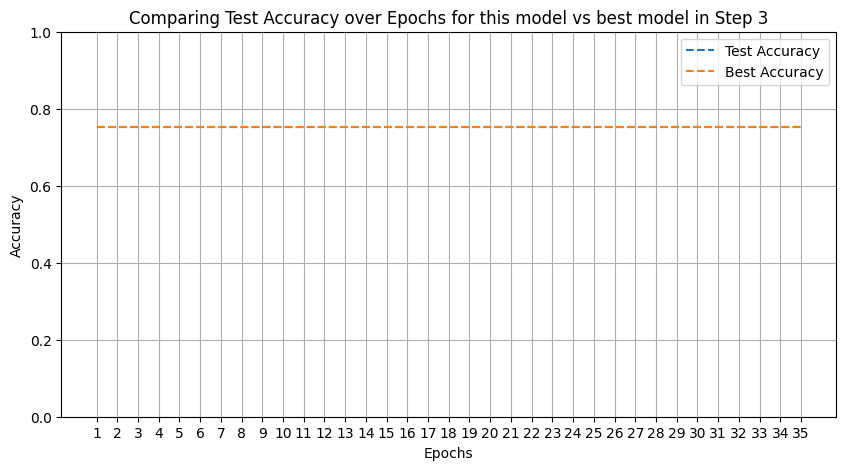

In [170]:
#Checking accuracy on test dataset
model.eval()
test_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        test_loss += loss_function(outputs, labels.unsqueeze(1)).item()
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy on test data: {accuracy}")
print(f"Test Loss: {test_loss / len(test_loader)}")

test_accuracy = accuracy

test_accuracy_list = [test_accuracy] * epochs
best_accuracy_list = [best_accuracy] * epochs

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), test_accuracy_list, label='Test Accuracy', linestyle='--')
plt.plot(range(1, epochs + 1), best_accuracy_list, label='Best Accuracy', linestyle='--')

plt.title('Comparing Test Accuracy over Epochs for this model vs best model in Step 3')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(np.arange(1, epochs + 1, step=1))
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()

##Early Stopping

In [232]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super(NeuralNetwork, self).__init__()

    #self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
      nn.Linear(7, 128),
      nn.ReLU(),
      nn.Dropout(0.4),
      nn.Linear(128, 64),
      nn.ReLU(),
      nn.Dropout(0.4),
      nn.Linear(64, 1),
      nn.Sigmoid()
      )
  def forward(self, x):
    #x = self.flatten(x)
    x = self.linear_relu_stack(x)
    return x

In [242]:
import copy

class EarlyStopping:
    def __init__(self, patience=12, delta=-0.01, verbose=False, path='best_model.pth'):

        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.path = path

        self.best_val_loss = float('inf')
        self.counter = 0
        self.early_stop = False
        self.best_model_weights = None

    def __call__(self, val_loss, model):
        if self.best_val_loss - val_loss > self.delta:
            self.best_val_loss = val_loss
            self.best_model_weights = copy.deepcopy(model.state_dict())
            self.counter = 0
            if self.verbose:
                print(f"Validation loss improved: {self.best_val_loss:.4f}")
        else:
            self.counter += 1
            if self.verbose:
                print(f"No improvement in validation loss. Counter: {self.counter}/{self.patience}")

        if self.counter >= self.patience:
            self.early_stop = True
            if self.verbose:
                print(f"Early stopping triggered! Best validation loss: {self.best_val_loss:.4f}")

    def load_best_model(self, model):
        model.load_state_dict(self.best_model_weights)

In [243]:
model = NeuralNetwork()
model.to(device)
print(summary(model, input_size=(1, num_of_features)))

loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
early_stopping = EarlyStopping(patience=12, verbose=True)
#NUM_ACCUMULATION_STEPS = 3

epochs = 35
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for idx, sample in enumerate(train_loader):
        inputs, labels = sample
        inputs, labels = inputs.to(device), labels.to(device)

        labels = labels.unsqueeze(1)
        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = loss_function(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(epoch_train_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_labels = val_labels.unsqueeze(1)
            val_outputs = model(val_inputs)

            epoch_val_loss += loss_function(val_outputs, val_labels).item()
            val_predicted = (val_outputs > 0.5).float()
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_val / total_val)


    # Print epoch results
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')

    early_stopping(val_losses[-1], model)

    if early_stopping.early_stop:
        print(f"Training stopped early at epoch {epoch + 1}")
        break

early_stopping.load_best_model(model)

print(f"Training time: {time.time() - start} seconds")

Layer (type:depth-idx)                   Output Shape              Param #
NeuralNetwork                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 128]                  1,024
│    └─ReLU: 2-2                         [1, 128]                  --
│    └─Dropout: 2-3                      [1, 128]                  --
│    └─Linear: 2-4                       [1, 64]                   8,256
│    └─ReLU: 2-5                         [1, 64]                   --
│    └─Dropout: 2-6                      [1, 64]                   --
│    └─Linear: 2-7                       [1, 1]                    65
│    └─Sigmoid: 2-8                      [1, 1]                    --
Total params: 9,345
Trainable params: 9,345
Non-trainable params: 0
Total mult-adds (M): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04
Epoch 1/35

Accuracy on test data: 0.7792207792207793
Test Loss: 0.5207387208938599


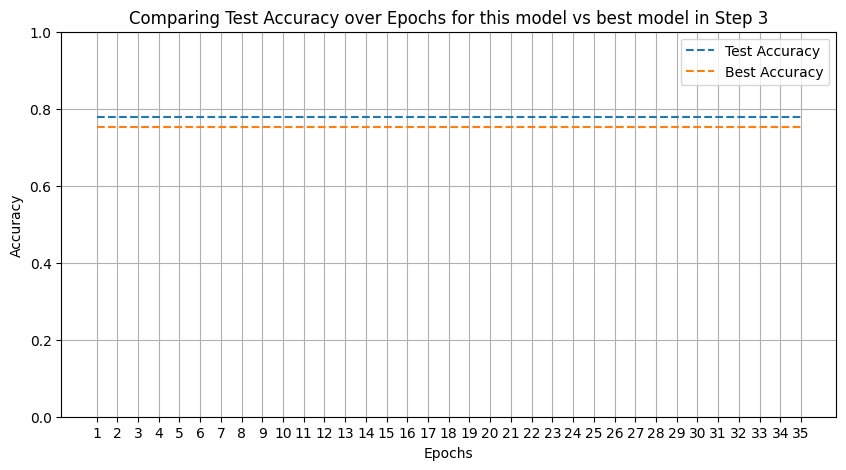

In [244]:
#Checking accuracy on test dataset
model.eval()
test_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        test_loss += loss_function(outputs, labels.unsqueeze(1)).item()
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy on test data: {accuracy}")
print(f"Test Loss: {test_loss / len(test_loader)}")

test_accuracy = accuracy

test_accuracy_list = [test_accuracy] * epochs
best_accuracy_list = [best_accuracy] * epochs

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), test_accuracy_list, label='Test Accuracy', linestyle='--')
plt.plot(range(1, epochs + 1), best_accuracy_list, label='Best Accuracy', linestyle='--')

plt.title('Comparing Test Accuracy over Epochs for this model vs best model in Step 3')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(np.arange(1, epochs + 1, step=1))
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()

Saving this model since we found an improvement in test accuracy:

In [245]:
torch.save(model.state_dict(), 'early_stop_model.pth')

In [246]:
test_accuracy = accuracy
test_loss = test_loss / len(test_loader)

test_accuracy_list = [test_accuracy] * epochs
test_loss_list = [test_loss] * epochs

print(test_accuracy_list)
print(test_loss_list)

[0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793, 0.7792207792207793]
[0.5207387208938599, 0.5207387208938599, 0.5207387208938599, 0.5207387208938599, 0.5207387208938599, 0.5207387208938599, 0.5207387208938599, 0.5207387208938599, 0.5207387208938599, 0.5207387208938599, 0.5207387208938599, 0.5207387208938599, 0.5207387208938599, 0.5207387208938599, 0.5207387208938599

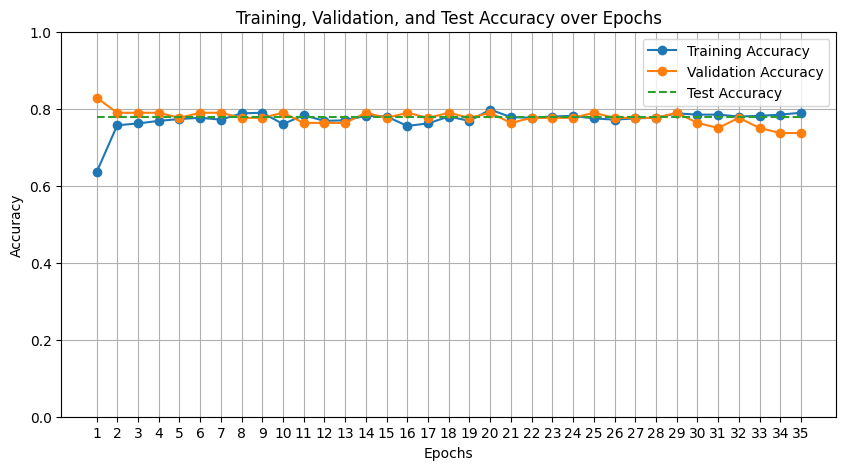

In [247]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_accuracies, label='Training Accuracy', marker='o')
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', marker='o')
plt.plot(range(1, epochs + 1), test_accuracy_list, label='Test Accuracy', linestyle='--')

plt.title('Training, Validation, and Test Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(np.arange(1, epochs + 1, step=1))
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()

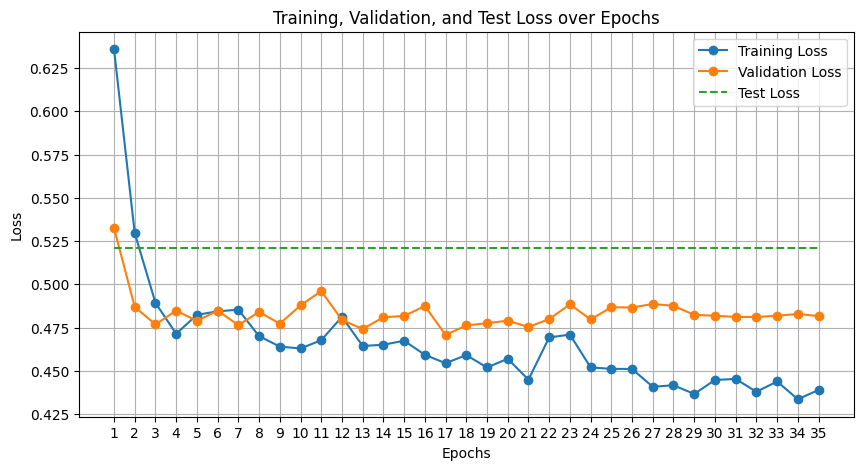

In [248]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', marker='o')
plt.plot(range(1, epochs + 1), test_loss_list, label='Test Loss', linestyle='--')

plt.title('Training, Validation, and Test Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(np.arange(1, epochs + 1, step=1))
plt.grid()
plt.legend()
plt.show()

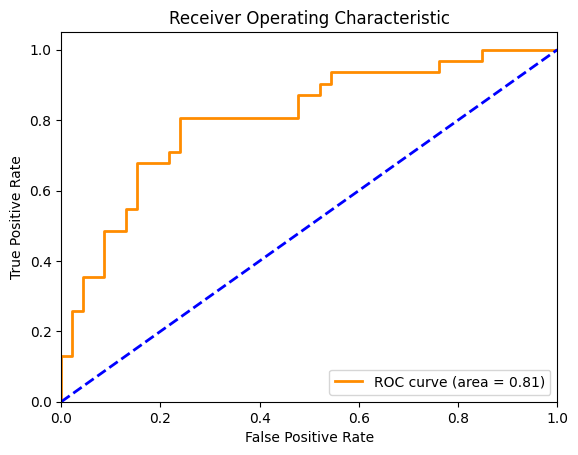

In [249]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_score, recall_score, f1_score

model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        y_true.extend(labels.cpu().numpy())
        y_scores.extend(outputs.cpu().numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores).flatten()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Precision: 0.75
Recall: 0.6774193548387096
F1-score: 0.711864406779661


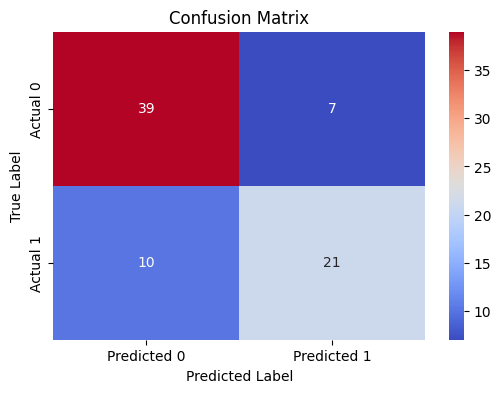

In [250]:
# Confusion Matrix & Precision, Recall, F1-Score
y_pred = (y_scores > 0.5).astype(int)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

##Gradient Accumulation

In [256]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super(NeuralNetwork, self).__init__()

    #self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
      nn.Linear(7, 128),
      nn.ReLU(),
      nn.Dropout(0.4),
      nn.Linear(128, 64),
      nn.ReLU(),
      nn.Dropout(0.4),
      nn.Linear(64, 1),
      nn.Sigmoid()
      )
  def forward(self, x):
    #x = self.flatten(x)
    x = self.linear_relu_stack(x)
    return x

In [259]:
model = NeuralNetwork()
model.to(device)
print(summary(model, input_size=(1, num_of_features)))

loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
NUM_ACCUMULATION_STEPS = 3

epochs = 35
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for idx, sample in enumerate(train_loader):
        inputs, labels = sample
        inputs, labels = inputs.to(device), labels.to(device)

        labels = labels.unsqueeze(1)
        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = loss_function(outputs, labels)
        loss = loss / NUM_ACCUMULATION_STEPS

        # Backpropagation
        loss.backward()
        if ((idx + 1) % NUM_ACCUMULATION_STEPS == 0) or (idx + 1 == len(train_loader)):
          optimizer.step()
          optimizer.zero_grad()

        epoch_train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(epoch_train_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_labels = val_labels.unsqueeze(1)
            val_outputs = model(val_inputs)

            epoch_val_loss += loss_function(val_outputs, val_labels).item()
            val_predicted = (val_outputs > 0.5).float()
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_val / total_val)


    # Print epoch results
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]}')

print(f"Training time: {time.time() - start} seconds")

Layer (type:depth-idx)                   Output Shape              Param #
NeuralNetwork                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 128]                  1,024
│    └─ReLU: 2-2                         [1, 128]                  --
│    └─Dropout: 2-3                      [1, 128]                  --
│    └─Linear: 2-4                       [1, 64]                   8,256
│    └─ReLU: 2-5                         [1, 64]                   --
│    └─Dropout: 2-6                      [1, 64]                   --
│    └─Linear: 2-7                       [1, 1]                    65
│    └─Sigmoid: 2-8                      [1, 1]                    --
Total params: 9,345
Trainable params: 9,345
Non-trainable params: 0
Total mult-adds (M): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04
Epoch 1/35

Accuracy on test data: 0.7532467532467533
Test Loss: 0.5307302594184875


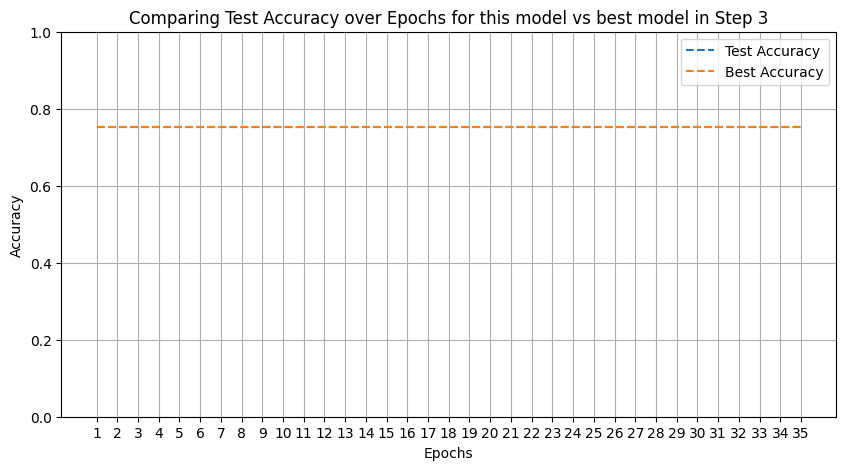

In [260]:
#Checking accuracy on test dataset
model.eval()
test_loss = 0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        test_loss += loss_function(outputs, labels.unsqueeze(1)).item()
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy on test data: {accuracy}")
print(f"Test Loss: {test_loss / len(test_loader)}")

test_accuracy = accuracy

test_accuracy_list = [test_accuracy] * epochs
best_accuracy_list = [best_accuracy] * epochs

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), test_accuracy_list, label='Test Accuracy', linestyle='--')
plt.plot(range(1, epochs + 1), best_accuracy_list, label='Best Accuracy', linestyle='--')

plt.title('Comparing Test Accuracy over Epochs for this model vs best model in Step 3')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(np.arange(1, epochs + 1, step=1))
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()

##Best model - with Early Stopping

In [261]:
#Loading best_model to cross-check if weights were saved properly
best_model = NeuralNetwork()
best_model.load_state_dict(torch.load('early_stop_model.pth'))
best_model.to(device)

#Checking accuracy on test dataset again
best_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.unsqueeze(1)).sum().item()

accuracy = correct / total
print(f"Accuracy using loaded model on test data: {accuracy}")

Accuracy using loaded model on test data: 0.7792207792207793


<ipython-input-261-9bfa442e1fee>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load('early_stop_model.pth'))


### NOTE:
Results for the best model (early stopping) already visualized in the respective experiment section earlier including:
1. Graph comparing train, val, test accuracies
2. Graph comparing train, val, test loss
3. Confusion matrix on test data
4. ROC curve
5. Precision, Recall and F1 score values

#References


1.   https://pytorch.org/docs/stable/generated/torch.nn.functional.normalize.html
2.   https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
3. https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
4. https://pytorch.org/docs/stable/nn.html
5. https://pytorch.org/docs/stable/nn.html#loss-functions
6. https://github.com/TylerYep/torchinfo
7. https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html
8. https://pytorch.org/docs/stable/optim.html
9. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html
10. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html
11. https://pytorch.org/tutorials/beginner/saving_loading_models.html
12. https://docs.python.org/3/library/time.html
13. https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html#torch.optim.lr_scheduler.ReduceLROnPlateau
14. https://pytorch.org/ignite/generated/ignite.handlers.early_stopping.EarlyStopping.html
15. https://datascience.stackexchange.com/questions/61858/oversampling-undersampling-only-train-set-only-or-both-train-and-validation-set
16.

